In [ ]:
import os
import sys
import gc
from pathlib import Path   
os.chdir('/zhome/71/c/146676/texture_tomography')
sys.path.append('/zhome/71/c/146676/texture_tomography/package/odf_mumott')
import h5py
import numpy as np

from package.texture_tomography.operators.pfo_and_projection_batched_opencl import PFO_OPENCL_BATCHED

import matplotlib.pyplot as plt
from multiprocessing import Pool
import yaml


from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_huber_opencl import FISTAHuberOpenCL
from package.texture_tomography.gpu_live_tracker import GPUMemoryLogger
from package.texture_tomography.operators.operator_memory_model import OperatorMemoryModel
from package.texture_tomography.operators.memory_tracker import MemoryCounter
from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_memory_model import FISTAMemoryModel
from package.texture_tomography.material import Material
import pyopencl.array as clarray

from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

from package.texture_tomography.operators.create_pfo_matrix import pfmatrix_sparseeval_gpu,sparse_pf_innerprod_gpu,interp_theta_4d_gpu, interp_theta_3d_gpu, build_pfsparse_program, sum_over_x_gpu, clip_nonnegative_gpu
from package.texture_tomography.multiresolution_refiner import OrientationTree, OrientationNode, generate_hopf_grid_fzone, invert_grid

import pyopencl as cl
from scipy.spatial.transform import Rotation as ROT

In [ ]:
config_path = "configs/bb_config_1.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

grid_resolution_parameter = cfg['grid_resolution_parameter']
kernel_sigma = cfg['kernel_sigma']
N_theta = cfg['N_theta']
N_chi = cfg['N_chi']
N_rot = cfg['N_rot']
Nx = cfg['Nx']
Ny = cfg['Ny']
peak_width = cfg['peak_width']
datapath = cfg["datapath"]
absorption_file = cfg['absorption_file']
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
cor_offset = cfg["cor_offset"]
N_seg = N_theta*N_chi
filename = cfg['integrated_file']
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']


In [10]:
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
N_mat = len(filenames)

materials = []

for i_mat in range(N_mat):
    path = cif_folder / filenames[i_mat]
    material = Material.from_cif(
        cif_path=path,
        wavelength_kev=wavelength_kev,
        min_two_theta=min_two_theta,
        max_two_theta=max_two_theta,
        intensity_cutoff_fraction=reflection_cutoff,
    )
    materials.append(material)



In [14]:
grid_resolution_parameter = 6      # example
kernel_sigma = 0.25                # example
sigma_levels = [kernel_sigma]      # start with single level

grids = []

for mat in materials:
    tree = OrientationTree.from_hopf_fzone(
        mat.point_group_matrices,
        grid_resolution_parameter=grid_resolution_parameter,
        sigma_levels=sigma_levels,
    )
    grids.append(tree)

In [5]:
with h5py.File(datapath + absorption_file, 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dtc= file['entry/instrument/xspress3']
    data_all_events = dtc['all_events'][:].reshape(181,362)
    data_output_count_rate = dtc['output_count_rate'][:].reshape(181,362)
    data_att = dtc['window_counts'][:][:,0].reshape(181,362)


print('Loaded shape:', data_att.shape)



N_workers = 16  # adjust to match available CPUs

# --- Get list of dataset keys (exclude metadata) ---
with h5py.File(filename, 'r') as f:
    keys = [k for k in f.keys() if k != 'two_theta']
keys = sorted(keys, key=lambda x: int(x))


# --- Worker function ---
def load_single(key):
    with h5py.File(filename, 'r') as f:
        arr = f[key][...]
    return arr

with h5py.File(filename, 'r') as f:
    two_theta = f['two_theta'][:]


# --- Parallel load ---
with Pool(processes=N_workers) as pool:
    data_list = pool.map(load_single, keys)

# --- Combine into single array ---
data = np.stack(data_list, axis=0)

print('Loaded shape:', data.shape)
data_corrected = data/data_att[:,:,None,None]*100

Loaded shape: (181, 362)
Loaded shape: (181, 362, 90, 120)


In [12]:
all_data_reshaped = data_corrected.reshape((N_rot, Nx, N_chi*N_theta))

In [16]:
op = PFO_OPENCL_BATCHED(
        cfg = cfg,
        materials=materials,
        grids=grids,
        two_thetas = two_theta,
        verbose=False)
op.set_pf_batch_max_gb(2.5)

mem = MemoryCounter()

#op_model = OperatorMemoryModel(op, mem)

# fista = FISTAOpenCL(
#     operator=op,
#     prox_kind="nonneg",
#     lam=0.0,
#     tau=1e-3
# )

# fista_mem = FISTAMemoryModel(fista, mem, op_model)

# x_shape  = (op.Nx, op.Ny, op.K_sum)
# Ax_shape = (op.N_rot, op.Nx, op.N_chi * op.N_theta)

# fista_mem.model_run(x_shape, Ax_shape, niter=1)

# mem.report()
# mem.report_peak_allocations(min_mb=50)

In [17]:
print(op.K_sum)
print(op.K_list)
print(op.K_sum*op.Nx*op.Ny*4/1e6)
print(op.K_sum*op.N_rot*op.Nx*4/1e6)
## todo: Implement varying ODF-resolution for different materials. Consider scaling... should the ODF scale accordingly? 

3476
[ 22 444 148 148 444  83 444 218 888  74 218 218  22  22  83]
402.65984
911.017888


[iter    1/20] obj=2.558072e+05  f=2.558072e+05  g=0.000000e+00  ||x||=9.552079e-05  ||grad||=9.552078e+06  tau=1.000e-11  beta=0.000e+00
[iter    2/20] obj=2.250001e+05  f=2.250001e+05  g=0.000000e+00  ||x||=1.803541e-04  ||grad||=8.489510e+06  tau=1.000e-11  beta=2.818e-01
[iter    3/20] obj=1.935076e+05  f=1.935076e+05  g=0.000000e+00  ||x||=2.760859e-04  ||grad||=7.206093e+06  tau=1.000e-11  beta=4.340e-01
[iter    4/20] obj=1.649587e+05  f=1.649587e+05  g=0.000000e+00  ||x||=3.748432e-04  ||grad||=5.775536e+06  tau=1.000e-11  beta=5.311e-01
[iter    5/20] obj=1.427266e+05  f=1.427266e+05  g=0.000000e+00  ||x||=4.697114e-04  ||grad||=4.352018e+06  tau=1.000e-11  beta=5.988e-01
[iter    6/20] obj=1.277994e+05  f=1.277994e+05  g=0.000000e+00  ||x||=5.554798e-04  ||grad||=3.097838e+06  tau=1.000e-11  beta=6.489e-01
[iter    7/20] obj=1.189970e+05  f=1.189970e+05  g=0.000000e+00  ||x||=6.290128e-04  ||grad||=2.142602e+06  tau=1.000e-11  beta=6.876e-01
[iter    8/20] obj=1.141810e+05  f

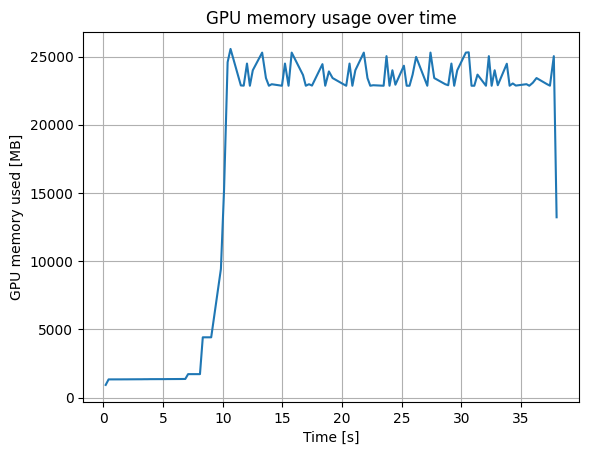

In [18]:
gpu_log = GPUMemoryLogger(interval=0.2, gpu_id=1)
gpu_log.start()


op = PFO_OPENCL_BATCHED(
        cfg = cfg,
        materials=materials,
        grids = grids,
        two_thetas = two_theta,
        verbose=False)

queue = op.queue
Nx, Ny, K = op.Nx, op.Ny, op.K_sum

x0_gpu = clarray.zeros(
    queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)
assert out_gpu.flags.c_contiguous
op.set_pf_batch_max_gb(1.5)
# l1 constant: 1e7
# tv constant: 2e-6
# L constant for l1: 5e11
solver = FISTAHuberOpenCL(op, prox_kind="nonneg", lam=1e2, L=1e11, huber_delta=0.1)


x_sol_gpu = solver.run(x0_gpu, out_gpu, niter=20, verbose=1, diagnostics_interval=1)
coeffs = x_sol_gpu.get().transpose((0,1,2))[::-1,::-1]
# op.free_memory()
# del x_sol_gpu
# del out_gpu
# del x0_gpu
# gc.collect()

gpu_log.stop()

t, mem = gpu_log.as_arrays()
import matplotlib.pyplot as plt

plt.plot(t, mem)
plt.xlabel("Time [s]")
plt.ylabel("GPU memory used [MB]")
plt.title("GPU memory usage over time")
plt.grid(True)
plt.show()


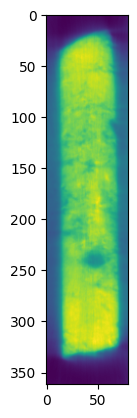

In [19]:
plt.imshow(coeffs.sum(axis=-1))

(362, 80, 3476)
[ 22 444 148 148 444  83 444 218 888  74 218 218  22  22  83]


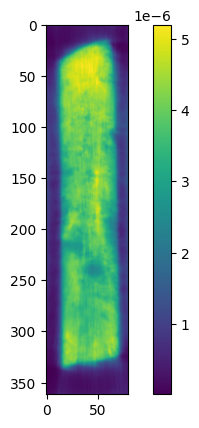

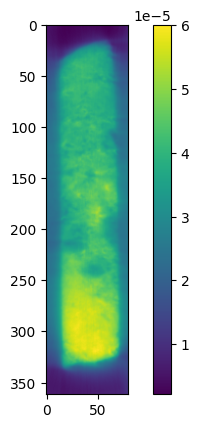

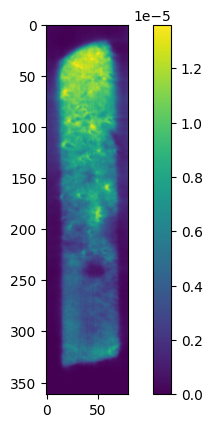

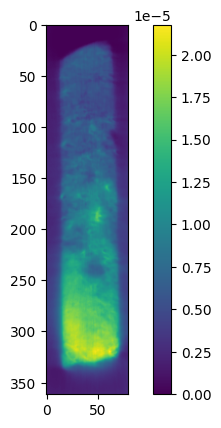

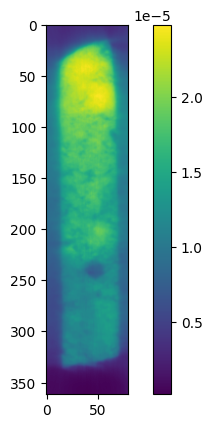

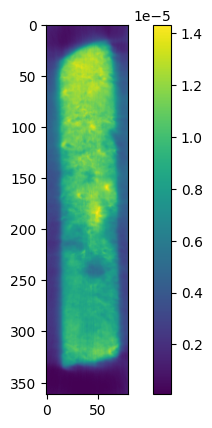

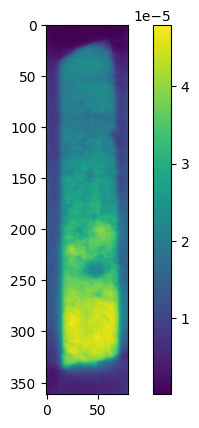

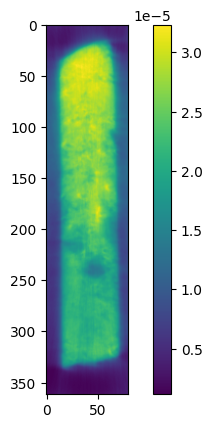

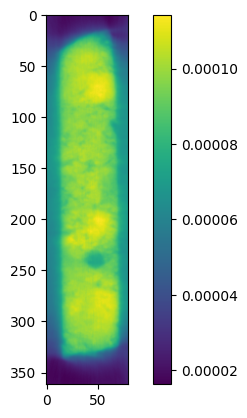

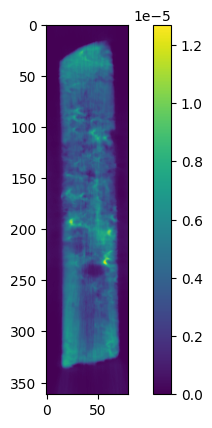

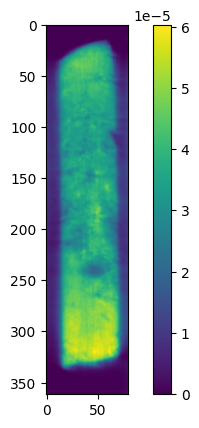

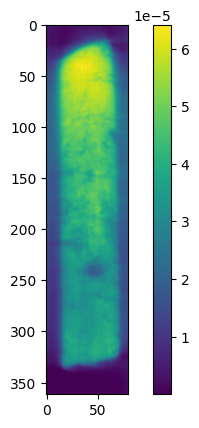

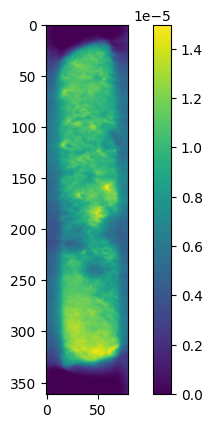

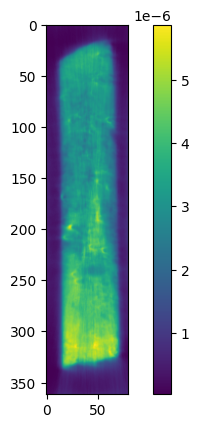

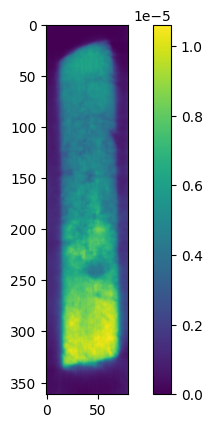

In [20]:
print(coeffs.shape)
print(op.K_list)
cumult_K_list = np.cumsum(np.concatenate([np.array([0]), np.array(op.K_list)]))
for i in range(op.N_mat):
    plt.imshow(coeffs[:,:,cumult_K_list[i]:cumult_K_list[i+1]].sum(axis=-1))
    plt.colorbar()
    plt.show()

In [21]:
print(cumult_K_list)

[   0   22  466  614  762 1206 1289 1733 1951 2839 2913 3131 3349 3371
 3393 3476]


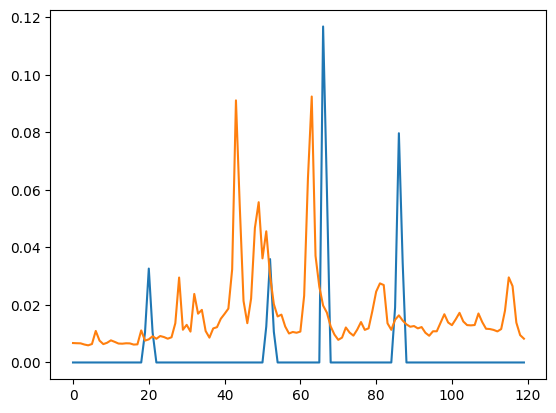

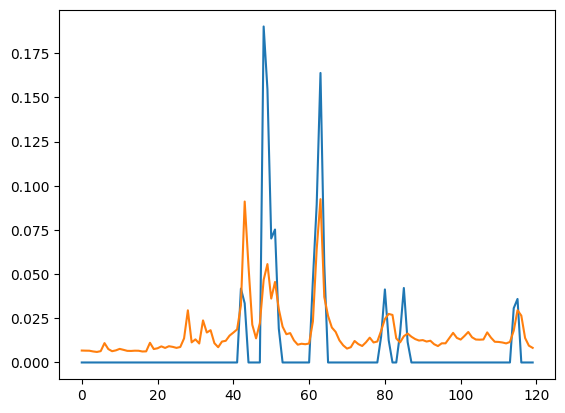

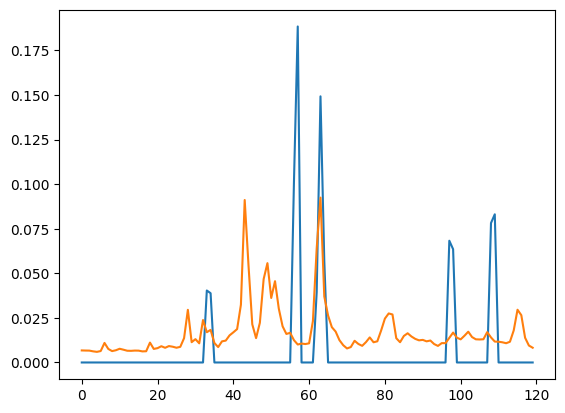

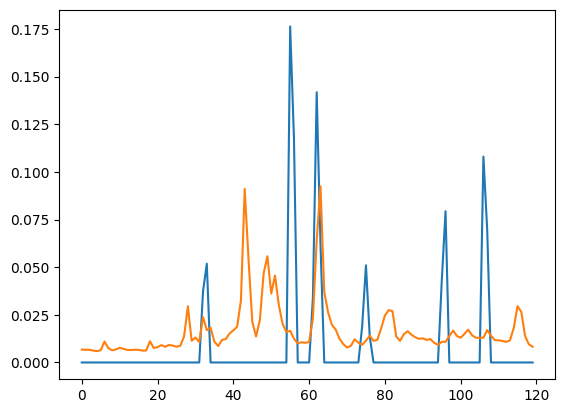

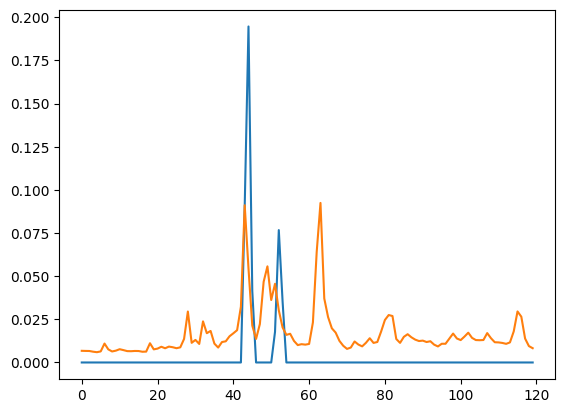

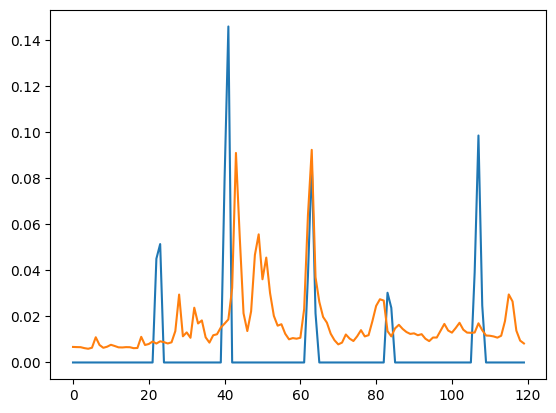

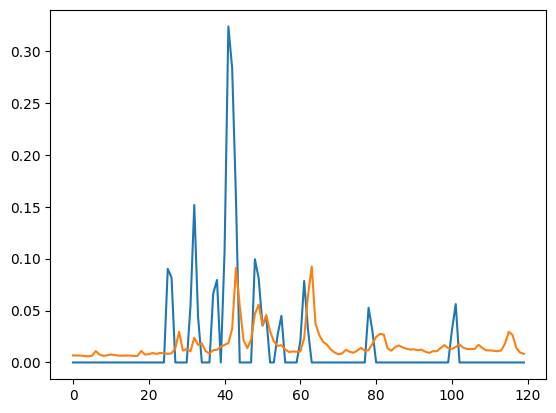

In [22]:


for i_basis in range(op.N_mat-8):

    arr_basis = clarray.zeros(
        queue,
        (Nx, Ny, K),
        dtype=np.float32,
        order="F"
    )
    arr_basis[:, :, cumult_K_list[i_basis]:cumult_K_list[i_basis+1]].fill(1.0)
    out_basis = clarray.empty(
        queue,
        (N_rot, Nx, N_seg),
        dtype=np.float32,
        order="C",
    )

    op.direct_cl(arr_basis, out_basis)
    out_cpu = out_basis.get().reshape((N_rot, Nx, N_chi, N_theta))

    y_basis1 = out_cpu.sum(axis=(0,1,2))
    y_data = data_corrected.sum(axis=(0,1,2))
    plt.plot(y_basis1/5e12)
    plt.plot(y_data/y_data.sum()*2)
    plt.show()

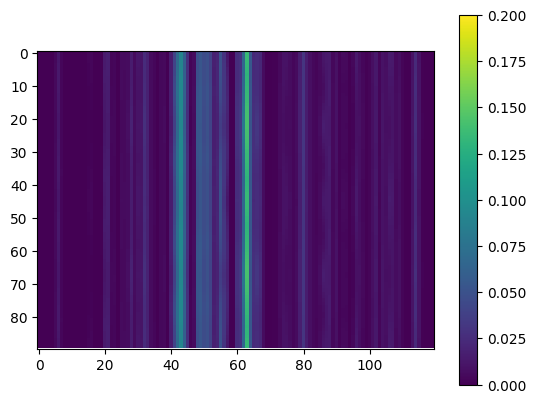

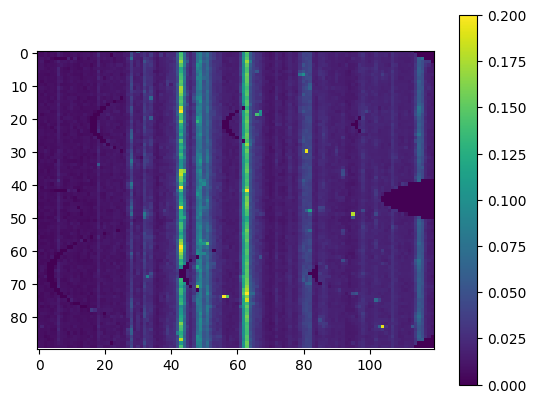

In [23]:
pf_prg = build_pfsparse_program(op.ctx)
kernel_pfmatrix_count_sparse = cl.Kernel(pf_prg, "pfmatrix_count_sparse")
kernel_pfmatrix_write_sparse = cl.Kernel(pf_prg, "pfmatrix_write_sparse")
kernel_sparse_pf_innerprod_4d = cl.Kernel(pf_prg, "sparse_pf_innerprod_4d")
kernel_interp3d = cl.Kernel(pf_prg, "interp_theta_3d")
kernel_interp4d = cl.Kernel(pf_prg, "interp_theta_4d")
kernel_sum_over_x = cl.Kernel(pf_prg, "sum_over_x")
kernel_clip_nonnegative = cl.Kernel(pf_prg, "clip_nonnegative")

prediction_gpu = op.direct(x_sol_gpu)
prediction_cpu = prediction_gpu.get().reshape((N_rot, Nx, N_chi, N_theta))
res_gpu = out_gpu - prediction_gpu
clip_nonnegative_gpu(op.queue, kernel_clip_nonnegative, res_gpu)
res_gpu = res_gpu.reshape((N_rot, Nx, N_chi, N_theta))

plt.imshow(prediction_cpu[0,90])
plt.colorbar()
plt.clim([0,0.2])
plt.show()

plt.imshow(data_corrected[0,90])
plt.colorbar()
plt.clim([0,0.2])
plt.show()
